In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

base = Path("..") / "runs" / "pass_decision"

hs_ws_df = pd.read_csv(base / "hs_ws_runs" / "decodability_results.csv")
noise_df = pd.read_csv(base / "noise_runs" / "decodability_results.csv")

msg_hs_ws_df = pd.read_csv(base / "hs_ws_runs" / "message_decodability_results.csv")
msg_noise_df = pd.read_csv(base / "noise_runs" / "message_decodability_results.csv")
msg_hs_ws_df["representation"] = msg_hs_ws_df["representation"].str.strip()
msg_noise_df["representation"] = msg_noise_df["representation"].str.strip()

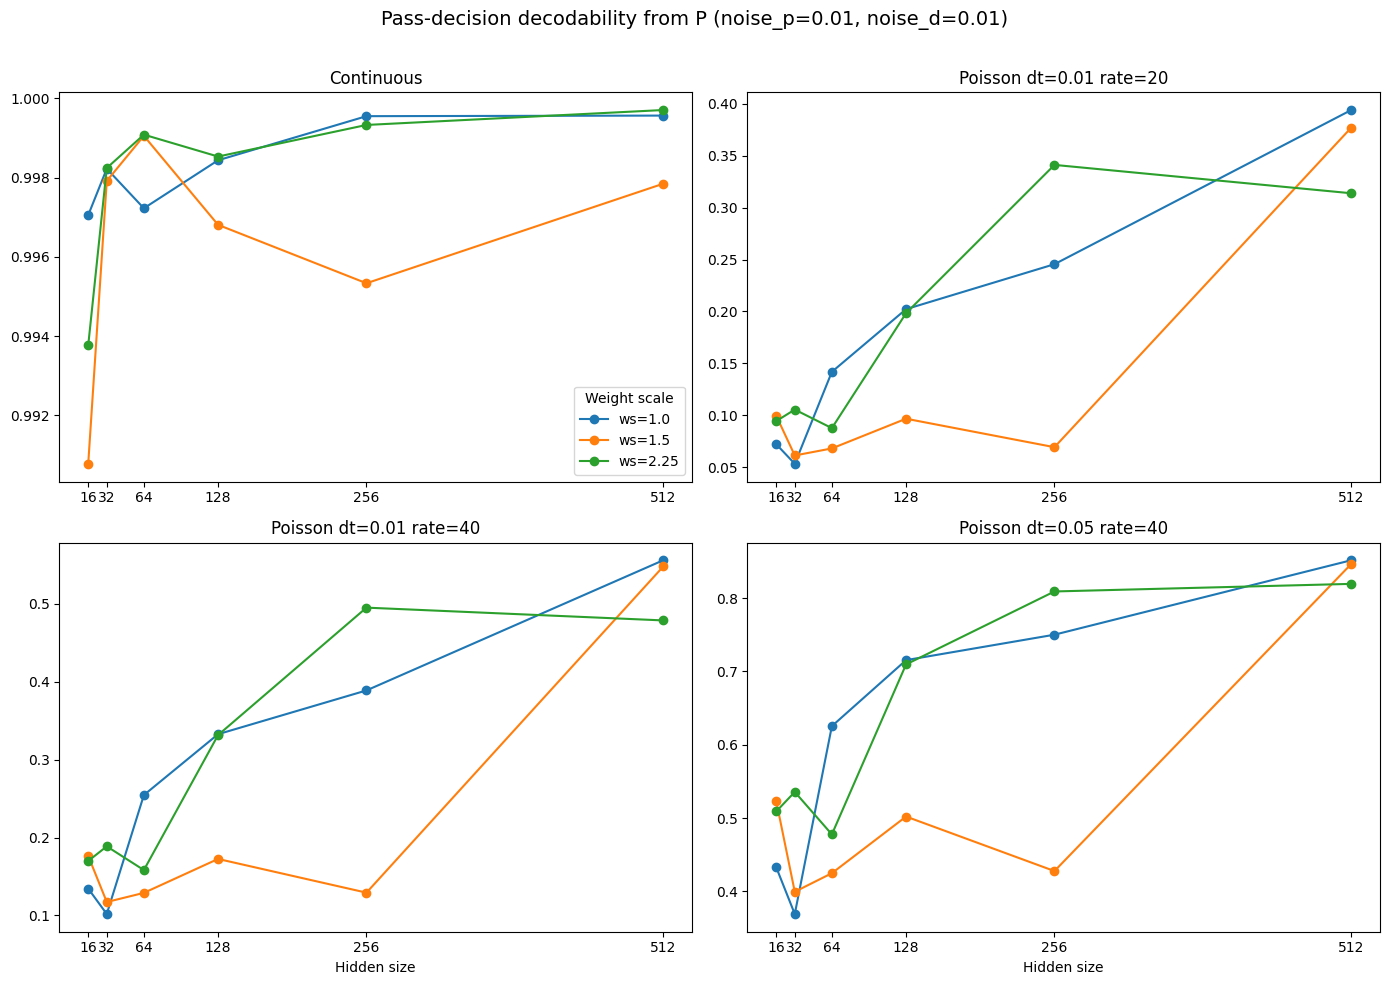

In [2]:
# Decodability by hidden size and input weight scale (decode from P)

metric_columns = {
    "score_continuous": "Continuous",
    "score_poisson_dt0.01_rate20": "Poisson dt=0.01 rate=20",
    "score_poisson_dt0.01_rate40": "Poisson dt=0.01 rate=40",
    "score_poisson_dt0.05_rate40": "Poisson dt=0.05 rate=40",
}

ws_values = sorted(hs_ws_df["ws"].unique())
hidden_sizes = sorted(hs_ws_df["hidden_size"].unique())
ws_colors = {ws: f"C{i}" for i, ws in enumerate(ws_values)}

decode_from = hs_ws_df["decode_from"].iloc[0]
noise_p = hs_ws_df["noise_p"].iloc[0]
noise_d = hs_ws_df["noise_d"].iloc[0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (metric, label) in zip(axes, metric_columns.items()):
    for ws in ws_values:
        color = ws_colors[ws]
        subset = hs_ws_df[hs_ws_df["ws"] == ws].sort_values("hidden_size")
        ax.plot(
            subset["hidden_size"],
            subset[metric],
            marker="o",
            linestyle="-",
            color=color,
            label=f"ws={ws}",
        )
        if ax == axes[2] or ax == axes[3]:
            ax.set_xlabel("Hidden size")

    ax.set_title(label)
    ax.set_xticks(hidden_sizes)
    ax.set_xticklabels([str(h) for h in hidden_sizes])

axes[0].legend(title="Weight scale")
fig.suptitle(
    f"Pass-decision decodability from {decode_from} "
    f"(noise_p={noise_p}, noise_d={noise_d})",
    fontsize=14,
)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

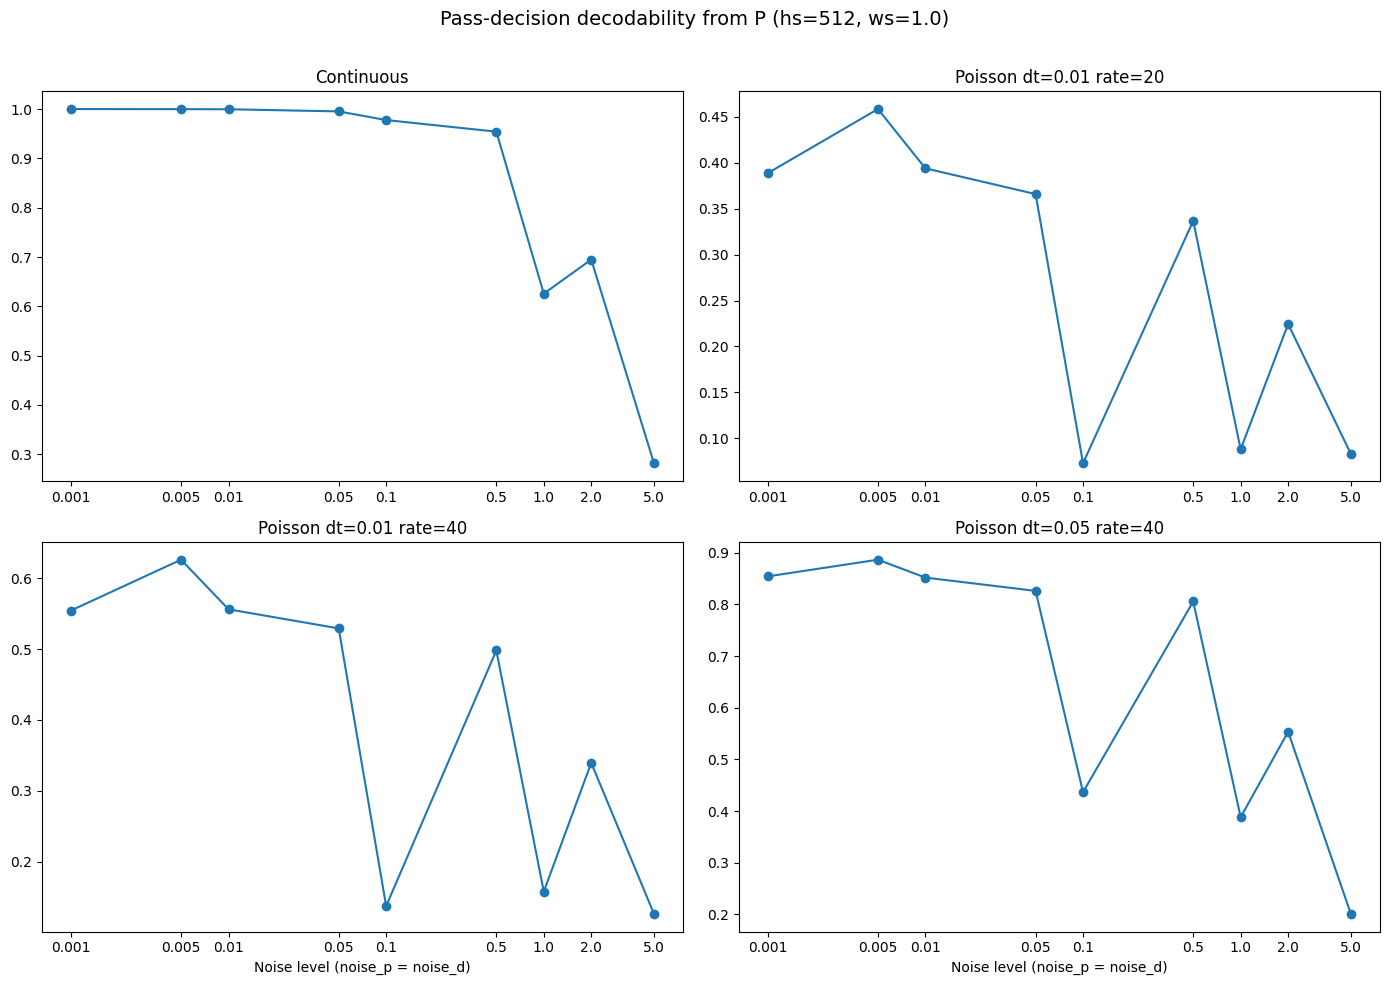

In [5]:
# Decodability by noise level (decode from P)

from matplotlib.ticker import FixedLocator, NullLocator

metric_columns = {
    "score_continuous": "Continuous",
    "score_poisson_dt0.01_rate20": "Poisson dt=0.01 rate=20",
    "score_poisson_dt0.01_rate40": "Poisson dt=0.01 rate=40",
    "score_poisson_dt0.05_rate40": "Poisson dt=0.05 rate=40",
}

noise_levels = sorted(noise_df["noise_p"].unique())
subset = noise_df.sort_values("noise_p")

decode_from = noise_df["decode_from"].iloc[0]
hidden_size = int(noise_df["hidden_size"].iloc[0])
ws = noise_df["ws"].iloc[0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (metric, label) in zip(axes, metric_columns.items()):
    ax.plot(
        subset["noise_p"],
        subset[metric],
        marker="o",
        linestyle="-",
        color="C0",
    )
    ax.set_xscale("log")
    ax.xaxis.set_major_locator(FixedLocator(noise_levels))
    ax.xaxis.set_minor_locator(NullLocator())
    ax.set_xticklabels([str(n) for n in noise_levels])
    ax.set_title(label)
    if ax == axes[2] or ax == axes[3]:
        ax.set_xlabel("Noise level (noise_p = noise_d)")

fig.suptitle(
    f"Pass-decision decodability from {decode_from} "
    f"(hs={hidden_size}, ws={ws})",
    fontsize=14,
)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [ ]:
# Message decodability: P vs D by hidden size and weight scale

from matplotlib.lines import Line2D

representation_columns = {
    "continuous": "Continuous",
    "poisson_dt0.01_rate20": "Poisson dt=0.01 rate=20",
    "poisson_dt0.01_rate40": "Poisson dt=0.01 rate=40",
    "poisson_dt0.05_rate40": "Poisson dt=0.05 rate=40",
}

ws_values = sorted(msg_hs_ws_df["ws"].unique())
hidden_sizes = sorted(msg_hs_ws_df["hidden_size"].unique())
ws_colors = {ws: f"C{i}" for i, ws in enumerate(ws_values)}

noise_p = msg_hs_ws_df["noise_p"].iloc[0]
noise_d = msg_hs_ws_df["noise_d"].iloc[0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (rep, label) in zip(axes, representation_columns.items()):
    rep_df = msg_hs_ws_df[msg_hs_ws_df["representation"] == rep]
    for ws in ws_values:
        color = ws_colors[ws]
        subset = rep_df[rep_df["ws"] == ws].sort_values("hidden_size")
        ax.plot(
            subset["hidden_size"],
            subset["r2_P"],
            marker="o",
            linestyle="-",
            color=color,
            label=f"ws={ws}",
        )
        ax.plot(
            subset["hidden_size"],
            subset["r2_D"],
            marker="o",
            linestyle=":",
            color=color,
            label="_nolegend_",
        )
        if ax == axes[2] or ax == axes[3]:
            ax.set_xlabel("Hidden size")

    ax.set_title(label)
    ax.set_xticks(hidden_sizes)
    ax.set_xticklabels([str(h) for h in hidden_sizes])

ws_handles, ws_labels = axes[0].get_legend_handles_labels()
style_handles = [
    Line2D([0], [0], color="k", linestyle="-", label="P (sender)"),
    Line2D([0], [0], color="k", linestyle=":", label="D (receiver)"),
]
axes[0].legend(handles=ws_handles + style_handles, labels=ws_labels + ["P (sender)", "D (receiver)"])
fig.suptitle(
    f"P→D message decodability (noise_p={noise_p}, noise_d={noise_d})",
    fontsize=14,
)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [ ]:
# Message decodability: P vs D by noise level

from matplotlib.lines import Line2D
from matplotlib.ticker import FixedLocator, NullLocator

representation_columns = {
    "continuous": "Continuous",
    "poisson_dt0.01_rate20": "Poisson dt=0.01 rate=20",
    "poisson_dt0.01_rate40": "Poisson dt=0.01 rate=40",
    "poisson_dt0.05_rate40": "Poisson dt=0.05 rate=40",
}

noise_levels = sorted(msg_noise_df["noise_p"].unique())
hidden_size = int(msg_noise_df["hidden_size"].iloc[0])
ws = msg_noise_df["ws"].iloc[0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (rep, label) in zip(axes, representation_columns.items()):
    subset = msg_noise_df[msg_noise_df["representation"] == rep].sort_values("noise_p")
    ax.plot(subset["noise_p"], subset["r2_P"], marker="o", linestyle="-", color="C0")
    ax.plot(subset["noise_p"], subset["r2_D"], marker="o", linestyle=":", color="C0")

    ax.set_title(label)
    ax.set_xscale("log")
    ax.xaxis.set_major_locator(FixedLocator(noise_levels))
    ax.xaxis.set_minor_locator(NullLocator())
    ax.set_xticklabels([str(n) for n in noise_levels])
    if ax == axes[2] or ax == axes[3]:
        ax.set_xlabel("Noise level (noise_p = noise_d)")

style_handles = [
    Line2D([0], [0], color="k", linestyle="-", label="P (sender)"),
    Line2D([0], [0], color="k", linestyle=":", label="D (receiver)"),
]
axes[0].legend(handles=style_handles)
fig.suptitle(
    f"P→D message decodability (hs={hidden_size}, ws={ws})",
    fontsize=14,
)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()